In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# Configuration
metrics_dir = "/home/paul/Msci/metrics/"
plot_dir = "/home/paul/Msci/plots/"

# Rolling window size for smoothing
rolling_window = 50

In [9]:
def load_training_metrics(filepath):
    """Load training metrics from CSV file."""
    df = pd.read_csv(filepath)
    return df

def add_rolling_averages(df, window=50):
    """Add rolling average columns for smoother plots."""
    df = df.copy()
    df['train_loss_smooth'] = df['train_loss'].rolling(window=window, min_periods=1).mean()
    df['test_loss_smooth'] = df['test_loss'].rolling(window=window, min_periods=1).mean()
    df['train_accu_smooth'] = df['train_accu'].rolling(window=window, min_periods=1).mean()
    df['test_accu_smooth'] = df['test_accu'].rolling(window=window, min_periods=1).mean()
    return df

def print_training_stats(df, name=""):
    """Print summary statistics for a training run."""
    print(f"\n=== Training Stats{' - ' + name if name else ''} ===")
    print(f"Final train accuracy: {df['train_accu'].iloc[-1]:.3f}")
    print(f"Final test accuracy: {df['test_accu'].iloc[-1]:.3f}")
    print(f"Final train loss: {df['train_loss'].iloc[-1]:.3f}")
    print(f"Final test loss: {df['test_loss'].iloc[-1]:.3f}")
    print(f"Total steps: {df['step'].iloc[-1]:.0f}")
    print(f"Total epochs: {df['epoch'].iloc[-1]:.0f}")
    
    # Best test accuracy
    best_idx = df['test_accu'].idxmax()
    print(f"\nBest test accuracy: {df['test_accu'].iloc[best_idx]:.3f} at step {df['step'].iloc[best_idx]:.0f}")

In [10]:
def plot_training_curves(df, title="Training Curves", show_raw=True, show_smooth=True, 
                         rolling_window=50, save_path=None, figsize=(14, 5)):
    """
    Plot training curves for a single run.
    
    Parameters:
    -----------
    df : DataFrame with columns: step, train_loss, test_loss, train_accu, test_accu
    title : str, plot title prefix
    show_raw : bool, show raw (unsmoothed) data
    show_smooth : bool, show rolling average smoothed data
    rolling_window : int, window size for rolling average
    save_path : str or None, path to save figure (without extension)
    figsize : tuple, figure size
    """
    
    # Add rolling averages if needed
    if show_smooth:
        df = add_rolling_averages(df, window=rolling_window)
    
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    
    # Plot 1: Loss curves
    if show_raw:
        axes[0].plot(df['step'], df['train_loss'], alpha=0.3, color='blue')
        axes[0].plot(df['step'], df['test_loss'], alpha=0.3, color='orange')
    if show_smooth:
        axes[0].plot(df['step'], df['train_loss_smooth'], label='Train Loss', color='blue', linewidth=2)
        axes[0].plot(df['step'], df['test_loss_smooth'], label='Test Loss', color='orange', linewidth=2)
    else:
        axes[0].plot(df['step'], df['train_loss'], label='Train Loss', alpha=0.7)
        axes[0].plot(df['step'], df['test_loss'], label='Test Loss', alpha=0.7)
    
    axes[0].set_xlabel('Step', fontsize=12)
    axes[0].set_ylabel('Loss', fontsize=12)
    axes[0].set_title(f'{title} - Loss', fontsize=14)
    axes[0].legend(fontsize=11)
    axes[0].grid(True, alpha=0.3)
    
    # Plot 2: Accuracy curves
    if show_raw:
        axes[1].plot(df['step'], df['train_accu'], alpha=0.3, color='blue')
        axes[1].plot(df['step'], df['test_accu'], alpha=0.3, color='orange')
    if show_smooth:
        axes[1].plot(df['step'], df['train_accu_smooth'], label='Train Accuracy', color='blue', linewidth=2)
        axes[1].plot(df['step'], df['test_accu_smooth'], label='Test Accuracy', color='orange', linewidth=2)
    else:
        axes[1].plot(df['step'], df['train_accu'], label='Train Accuracy', alpha=0.7)
        axes[1].plot(df['step'], df['test_accu'], label='Test Accuracy', alpha=0.7)
    
    axes[1].set_xlabel('Step', fontsize=12)
    axes[1].set_ylabel('Accuracy', fontsize=12)
    axes[1].set_title(f'{title} - Accuracy', fontsize=14)
    axes[1].legend(fontsize=11)
    axes[1].grid(True, alpha=0.3)
    axes[1].set_ylim(0, 1.05)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(f"{save_path}.png", dpi=300, bbox_inches='tight')
        plt.savefig(f"{save_path}.pdf", bbox_inches='tight')
        print(f"Saved: {save_path}.png and .pdf")
    
    plt.show()
    
    return fig, axes

In [11]:
def plot_multiple_runs(runs_dict, metric='test_accu', show_smooth=True, rolling_window=50,
                       title="Comparison", save_path=None, figsize=(10, 6)):
    """
    Plot multiple training runs on the same graph for comparison.
    
    Parameters:
    -----------
    runs_dict : dict, {run_name: dataframe} pairs
    metric : str, which metric to plot ('train_loss', 'test_loss', 'train_accu', 'test_accu')
    show_smooth : bool, show rolling average smoothed data
    rolling_window : int, window size for rolling average
    title : str, plot title
    save_path : str or None, path to save figure
    figsize : tuple, figure size
    """
    
    fig, ax = plt.subplots(figsize=figsize)
    
    colors = plt.cm.tab10(np.linspace(0, 1, len(runs_dict)))
    
    for (name, df), color in zip(runs_dict.items(), colors):
        if show_smooth:
            df = add_rolling_averages(df, window=rolling_window)
            smooth_col = f"{metric}_smooth"
            ax.plot(df['step'], df[metric], alpha=0.2, color=color)
            ax.plot(df['step'], df[smooth_col], label=name, color=color, linewidth=2)
        else:
            ax.plot(df['step'], df[metric], label=name, alpha=0.7, color=color)
    
    ax.set_xlabel('Step', fontsize=12)
    ax.set_ylabel(metric.replace('_', ' ').title(), fontsize=12)
    ax.set_title(title, fontsize=14)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    
    if 'accu' in metric:
        ax.set_ylim(0, 1.05)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(f"{save_path}.png", dpi=300, bbox_inches='tight')
        plt.savefig(f"{save_path}.pdf", bbox_inches='tight')
        print(f"Saved: {save_path}.png and .pdf")
    
    plt.show()
    
    return fig, ax


def plot_multiple_runs_grid(runs_dict, show_smooth=True, rolling_window=50,
                            title="Training Comparison", save_path=None, figsize=(14, 10)):
    """
    Plot multiple training runs with all 4 metrics in a 2x2 grid.
    """
    
    fig, axes = plt.subplots(2, 2, figsize=figsize)
    metrics = ['train_loss', 'test_loss', 'train_accu', 'test_accu']
    titles = ['Train Loss', 'Test Loss', 'Train Accuracy', 'Test Accuracy']
    
    colors = plt.cm.tab10(np.linspace(0, 1, len(runs_dict)))
    
    for ax, metric, mtitle in zip(axes.flat, metrics, titles):
        for (name, df), color in zip(runs_dict.items(), colors):
            if show_smooth:
                df = add_rolling_averages(df, window=rolling_window)
                smooth_col = f"{metric}_smooth"
                ax.plot(df['step'], df[metric], alpha=0.15, color=color)
                ax.plot(df['step'], df[smooth_col], label=name, color=color, linewidth=2)
            else:
                ax.plot(df['step'], df[metric], label=name, alpha=0.7, color=color)
        
        ax.set_xlabel('Step', fontsize=11)
        ax.set_ylabel(mtitle, fontsize=11)
        ax.set_title(mtitle, fontsize=12)
        ax.grid(True, alpha=0.3)
        
        if 'Accuracy' in mtitle:
            ax.set_ylim(0, 1.05)
    
    # Single legend for all subplots
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', ncol=len(runs_dict), fontsize=11, bbox_to_anchor=(0.5, 1.02))
    
    plt.suptitle(title, fontsize=14, y=1.05)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(f"{save_path}.png", dpi=300, bbox_inches='tight')
        plt.savefig(f"{save_path}.pdf", bbox_inches='tight')
        print(f"Saved: {save_path}.png and .pdf")
    
    plt.show()
    
    return fig, axes

Saved: /home/paul/Msci/plots/multiclass_training_curves.png and .pdf


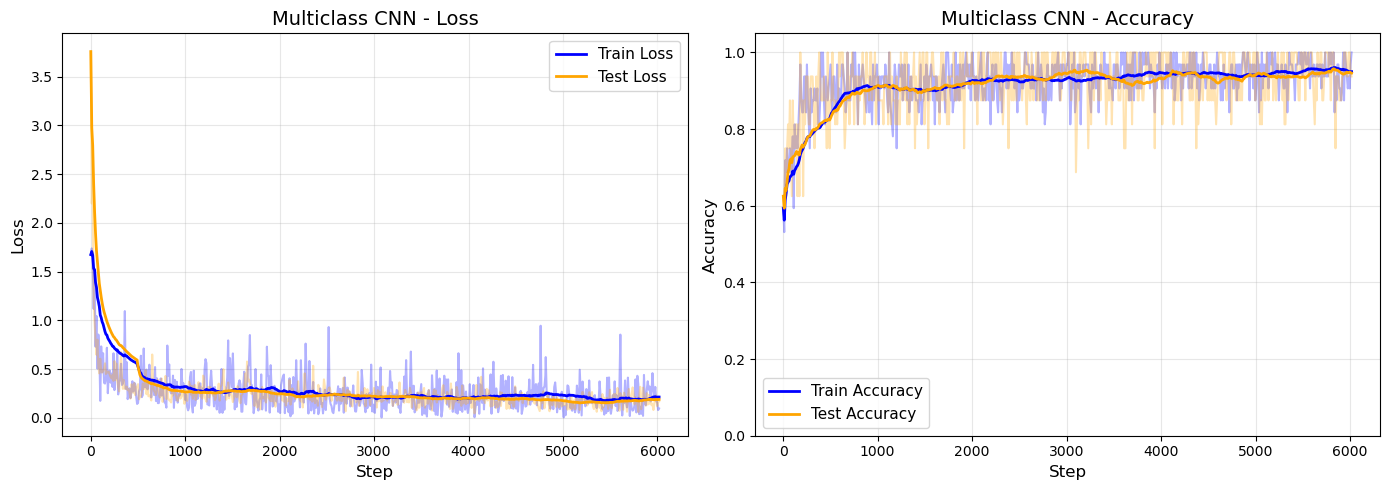


=== Training Stats - Multiclass ===
Final train accuracy: 1.000
Final test accuracy: 0.938
Final train loss: 0.098
Final test loss: 0.169
Total steps: 6017
Total epochs: 4

Best test accuracy: 1.000 at step 181


In [12]:
# Load a single training run
filepath = metrics_dir + "DM-CNN_training_metrics_20251208-03_21_PM_multiclass_run.csv"
df = load_training_metrics(filepath)

# Plot with rolling window smoothing
plot_training_curves(df, title="Multiclass CNN", show_raw=True, show_smooth=True, 
                     rolling_window=50, save_path=plot_dir + "multiclass_training_curves")

# Print stats
print_training_stats(df, name="Multiclass")

Saved: /home/paul/Msci/plots/accuracy_comparison.png and .pdf


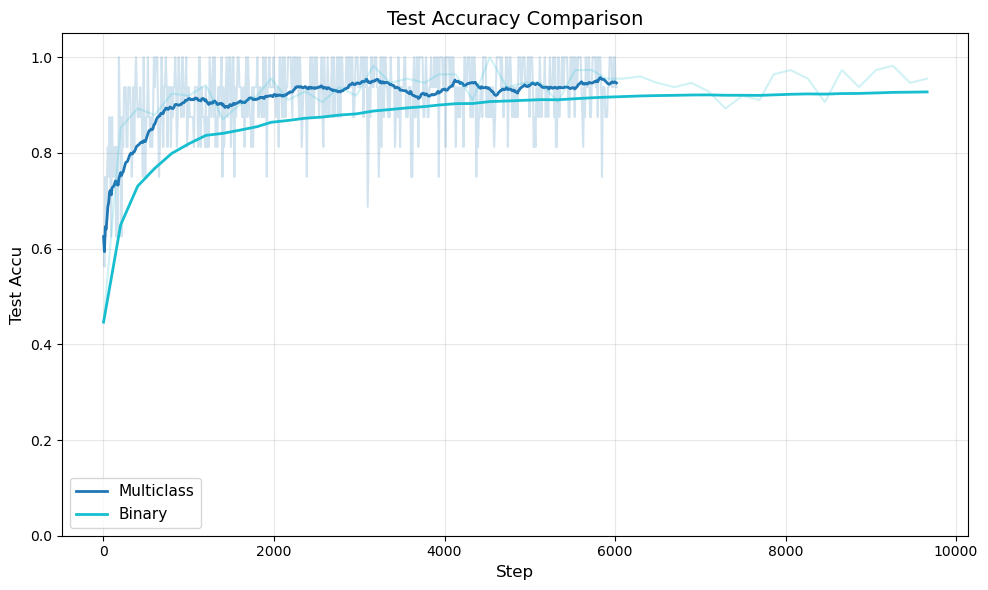

(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'Test Accuracy Comparison'}, xlabel='Step', ylabel='Test Accu'>)

In [13]:
# Load multiple runs for comparison
runs = {
    "Multiclass": load_training_metrics(metrics_dir + "DM-CNN_training_metrics_20251208-03_21_PM_multiclass_run.csv"),
    # Add more runs here:
    "Binary": load_training_metrics(metrics_dir + "DM-CNN_training_metrics_20251209-01_02_PM_0.001_AG_GN_LM_TRAINING.csv"),
    # "Run 3": load_training_metrics(metrics_dir + "third_run.csv"),
}

# Compare test accuracy across runs
plot_multiple_runs(runs, metric='test_accu', show_smooth=True, rolling_window=50,
                   title="Test Accuracy Comparison", save_path=plot_dir + "accuracy_comparison")

# Or plot all metrics in a grid
# plot_multiple_runs_grid(runs, show_smooth=True, rolling_window=50,
#                         title="Training Comparison", save_path=plot_dir + "full_comparison")

In [14]:
def analyze_convergence(df, name=""):
    """Analyze if training has converged."""
    
    # Compare early vs late training
    early = df.iloc[len(df)//4 : len(df)//2]  # 25-50% of training
    late = df.tail(len(df)//4)  # last 25%
    
    print(f"\n=== Convergence Analysis{' - ' + name if name else ''} ===")
    print(f"Early training (25-50%) - avg test loss: {early['test_loss'].mean():.4f}")
    print(f"Late training (last 25%) - avg test loss: {late['test_loss'].mean():.4f}")
    print(f"Improvement: {(early['test_loss'].mean() - late['test_loss'].mean()) / early['test_loss'].mean() * 100:.1f}%")
    
    print(f"\nEarly training - avg test accuracy: {early['test_accu'].mean():.4f}")
    print(f"Late training - avg test accuracy: {late['test_accu'].mean():.4f}")
    
    # Check for overfitting
    gap = df['train_accu'].iloc[-1] - df['test_accu'].iloc[-1]
    print(f"\nTrain-Test accuracy gap: {gap:.3f}")
    if gap > 0.1:
        print("Possible overfitting (gap > 0.1)")
    else:
        print("No significant overfitting")

# Run analysis
analyze_convergence(df, name="Multiclass")


=== Convergence Analysis - Multiclass ===
Early training (25-50%) - avg test loss: 0.2339
Late training (last 25%) - avg test loss: 0.1743
Improvement: 25.5%

Early training - avg test accuracy: 0.9342
Late training - avg test accuracy: 0.9421

Train-Test accuracy gap: 0.062
No significant overfitting
